![](noise-diode-1.png)

![](noise-diode-2.png)


In [57]:
import json
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
noise_diode = {}
noise_diode['jupyter_url'] = "https://github.com/lafefspietz/twpa-noise-measurement-fall-2026/blob/main/noise-diode.ipynb"
noise_diode['json_url'] = "https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/noise-diode.json"
noise_diode['serial_number'] = "MY61410135"
noise_diode['model'] = "346B"
noise_diode['manufacturer'] = "Keysight"
noise_diode['voltage'] = "28"
noise_diode['fghz_cal'] = [0.01,0.1,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]
noise_diode['ENR_cal'] = [
    15.24,
    15.22,
    15.13,
    15.13,
    14.94,
    14.85,
    14.81,
    14.78,
    14.80,
    14.78,
    14.86,
    14.83,
    14.76,
    14.90,
    15.00,
    15.08,
    15.28,
    15.35,
    15.16,
    14.58
]
noise_diode['diode_noise_temperature_hot_cal'] = []
for index in np.arange(len(noise_diode['ENR_cal'])):
    noise_temperature_hot = 290.0*(10**(noise_diode['ENR_cal'][index]/10))
    noise_diode['diode_noise_temperature_hot_cal'].append(noise_temperature_hot)

noise_diode['fghz'] = np.linspace(3, 12,1001)
noise_diode['diode_noise_temperature_hot'] = np.interp(noise_diode['fghz'], noise_diode['fghz_cal'], noise_diode['diode_noise_temperature_hot_cal'])
noise_diode['diode_noise_temperature_cold'] = noise_diode['fghz']*0 + 290
k_boltzmann = 1.380649e-23
planck_constant = 6.62607015e-34
noise_diode['k_boltzmann'] = k_boltzmann
noise_diode['planck_constant'] = planck_constant
noise_diode['diode_noise_number_hot'] = k_boltzmann*noise_diode['diode_noise_temperature_hot']/(planck_constant*1e9*noise_diode['fghz'])
noise_diode['diode_noise_number_cold'] = k_boltzmann*noise_diode['diode_noise_temperature_cold']/(planck_constant*1e9*noise_diode['fghz'])

noise_diode['fghz'] = np.round(noise_diode['fghz'], 3).tolist() # 3 decimals for clean 0.009 steps
noise_diode['diode_noise_temperature_hot'] = np.round(noise_diode['diode_noise_temperature_hot'], 2).tolist()
noise_diode['diode_noise_temperature_cold'] = np.round(noise_diode['diode_noise_temperature_cold'], 2).tolist()
noise_diode['diode_noise_number_hot'] = np.round(noise_diode['diode_noise_number_hot'], 4).tolist()
noise_diode['diode_noise_number_cold'] = np.round(noise_diode['diode_noise_number_cold'], 4).tolist()

with open("noise-diode.json", "w", encoding="utf-8") as f:
    json.dump(noise_diode, f, indent=4)


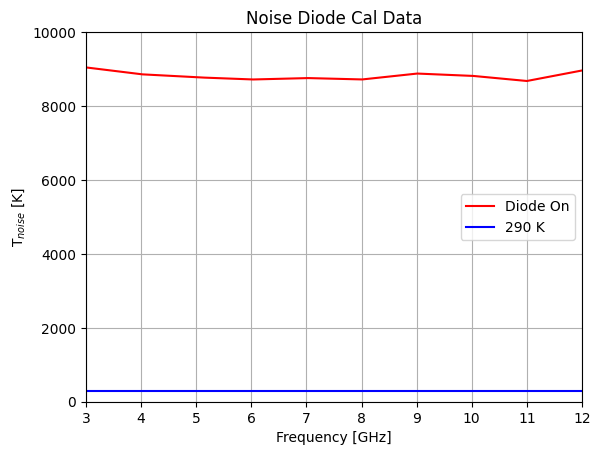

In [58]:
plt.plot(noise_diode['fghz'],noise_diode['diode_noise_temperature_hot'],color="red")
plt.plot(noise_diode['fghz'],noise_diode['diode_noise_temperature_cold'],color="blue")

plt.xlim(noise_diode['fghz'][0],noise_diode['fghz'][-1])
plt.ylim(0,10000)
plt.xlabel('Frequency [GHz]')
plt.ylabel('T$_{noise}$ [K]')
plt.grid()
plt.title('Noise Diode Cal Data')
plt.legend(['Diode On','290 K'])

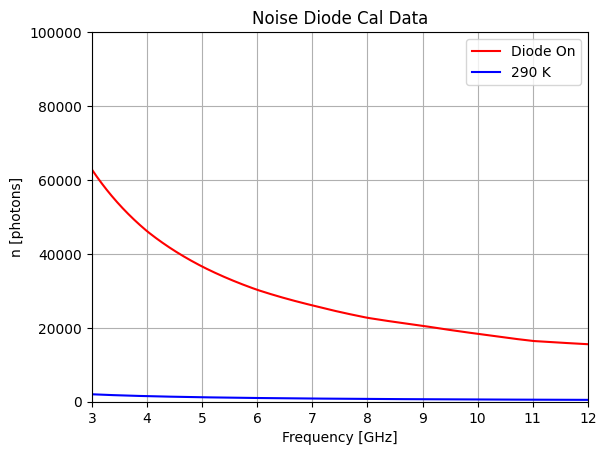

In [55]:
plt.plot(noise_diode['fghz'],noise_diode['diode_noise_number_hot'],color="red")
plt.plot(noise_diode['fghz'],noise_diode['diode_noise_number_cold'],color="blue")

plt.xlim(noise_diode['fghz'][0],noise_diode['fghz'][-1])
plt.ylim(0,100000)
plt.xlabel('Frequency [GHz]')
plt.ylabel('n [photons]')
plt.grid()
plt.title('Noise Diode Cal Data')
plt.legend(['Diode On','290 K'])

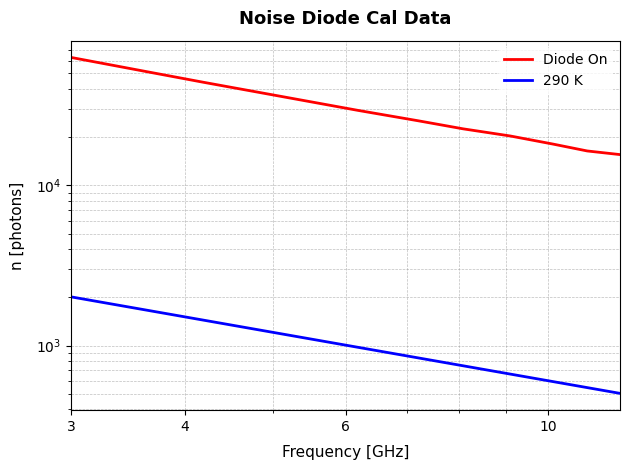

In [56]:
plt.loglog(
    noise_diode['fghz'], 
    noise_diode['diode_noise_number_hot'], 
    color="red", 
    linewidth=2, 
    label="Diode On"
)

plt.loglog(
    noise_diode['fghz'], 
    noise_diode['diode_noise_number_cold'], 
    color="blue", 
    linewidth=2, 
    label="290 K"
)

# FIXED: Added [0] to get the single starting value
plt.xlim(noise_diode['fghz'][0], noise_diode['fghz'][-1])

plt.xlabel('Frequency [GHz]', fontsize=11, labelpad=8)
plt.ylabel('n [photons]', fontsize=11, labelpad=8)
plt.title('Noise Diode Cal Data', fontsize=13, fontweight='bold', pad=12)

plt.xticks([3, 4, 6, 10], ['3', '4', '6', '10'])

plt.grid(True, which="both", linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10)
plt.tight_layout()

plt.show()


In [59]:
noise_diode

{'jupyter_url': 'https://github.com/lafefspietz/twpa-noise-measurement-fall-2026/blob/main/noise-diode.ipynb',
 'json_url': 'https://raw.githubusercontent.com/lafefspietz/twpa-noise-measurement-fall-2026/refs/heads/main/noise-diode.json',
 'serial_number': 'MY61410135',
 'model': '346B',
 'manufacturer': 'Keysight',
 'voltage': '28',
 'fghz_cal': [0.01,
  0.1,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18],
 'ENR_cal': [15.24,
  15.22,
  15.13,
  15.13,
  14.94,
  14.85,
  14.81,
  14.78,
  14.8,
  14.78,
  14.86,
  14.83,
  14.76,
  14.9,
  15.0,
  15.08,
  15.28,
  15.35,
  15.16,
  14.58],
 'diode_noise_temperature_hot_cal': [9691.656160757313,
  9647.127045526133,
  9449.264329058256,
  9449.264329058256,
  9044.779793872418,
  8859.271228324986,
  8778.048941493787,
  8717.621277621869,
  8757.859989165847,
  8717.621277621869,
  8879.693957702964,
  8818.566574461212,
  8677.567446163748,
  8961.856754289412,
  9170.6052144883,


$$P_{hot} = G(n + n_{hot})$$
$$P_{cold} = G(n + n_{cold})$$
$$G = \frac{P_{hot} - P_{cold}}{n_{hot} - n_{cold}}$$
$$n = \frac{P_{hot}}{G} - n_{hot}$$

G is gain in units of watts per photon

n is added noise number in units of photons
